求函数f(x,y)=3cos(xy)+4+x+y^2最小值，其中x∈ [-4,4], y∈ [−4,4]。\
参数：\
粒子个数N = 100，粒子维数D = 2；\
最大迭代次数T = 200；\
学习因子 C1 = C2 = 1.5；\
惯性权重最大值为 0.8，最小值为0.4；\
速度最大值为1，最小值为 -1。

最优解: x = -4.0000, y = 0.7539
最小值: f(x,y) = -2.4079


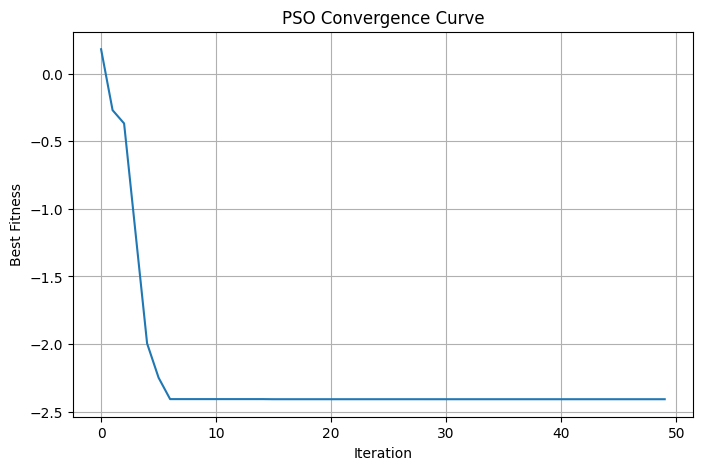

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class PSO:
    def __init__(self, func, bounds, n_particles=100, dim=2, max_iter=200,
                 c1=1.5, c2=1.5, w_max=0.8, w_min=0.4, v_max=1.0, v_min=-1.0):
        self.func = func
        self.bounds = bounds  # [min, max] for each dimension
        self.n_particles = n_particles
        self.dim = dim
        self.max_iter = max_iter
        self.c1 = c1
        self.c2 = c2
        self.w_max = w_max
        self.w_min = w_min
        self.v_max = v_max
        self.v_min = v_min
        
        # 初始化粒子群
        self.particles = np.random.uniform(bounds[0], bounds[1], (n_particles, dim))
        self.velocities = np.random.uniform(v_min, v_max, (n_particles, dim))
        
        # 记录个体最优位置和适应度
        self.pbest_pos = self.particles.copy() 
        self.pbest_fit = np.array([func(p) for p in self.particles])
        
        # 全局最优
        self.gbest_pos = self.pbest_pos[np.argmin(self.pbest_fit)]
        self.gbest_fit = np.min(self.pbest_fit)
        
        # 存储历史最优
        self.history = []

    def optimize(self):
        for t in range(self.max_iter):
            # 更新惯性权重（线性递减）
            w = self.w_max - (self.w_max - self.w_min) * t / self.max_iter
            
            # 更新速度 rand [0,1)
            # r1是个体的随机数
            # r2是群体的随机数
            r1, r2 = np.random.rand(self.n_particles, self.dim), np.random.rand(self.n_particles, self.dim)
            self.velocities = w * self.velocities + \
                              self.c1 * r1 * (self.pbest_pos - self.particles) + \
                              self.c2 * r2 * (self.gbest_pos - self.particles)
            
            # 限制速度
            self.velocities = np.clip(self.velocities, self.v_min, self.v_max)
            
            # 更新位置
            self.particles += self.velocities
            
            # 限制位置在边界内
            self.particles = np.clip(self.particles, self.bounds[0], self.bounds[1])


            # 计算当前适应度
            current_fit = np.array([self.func(p) for p in self.particles])
            
            # 更新个体最优（即如果当轮迭代，该个体比历史优化了，则记录
            improved = current_fit < self.pbest_fit   # 有改进标为True
            self.pbest_pos[improved] = self.particles[improved]
            self.pbest_fit[improved] = current_fit[improved]
            
            # 更新全局最优
            if np.min(current_fit) < self.gbest_fit:
                self.gbest_fit = np.min(current_fit)
                self.gbest_pos = self.particles[np.argmin(current_fit)].copy()

            # 记录历史
            self.history.append(self.gbest_fit)
        
        return self.gbest_pos, self.gbest_fit, self.history

# 定义目标函数
def objective_function(x):
    x, y = x[0], x[1]
    return 3 * np.cos(x * y) + 4 + x + y**2

# 设置参数
bounds = [-4, 4]  # x 和 y 的范围
N = 20  # 粒子数
D = 2    # 维数
T = 50  # 迭代次数
c1 = c2 = 1.5
w_max = 0.8
w_min = 0.4
v_max = 1.0
v_min = -1.0

# 创建 PSO 实例并求解
pso = PSO(
    func=objective_function,
    bounds=bounds,
    n_particles=N,
    dim=D,
    max_iter=T,
    c1=c1,
    c2=c2,
    w_max=w_max,
    w_min=w_min,
    v_max=v_max,
    v_min=v_min
)

# 执行优化
optimal_x, optimal_f, history = pso.optimize()

# 输出结果
print(f"最优解: x = {optimal_x[0]:.4f}, y = {optimal_x[1]:.4f}")
print(f"最小值: f(x,y) = {optimal_f:.4f}")

# 可视化收敛曲线
plt.figure(figsize=(8, 5))
plt.plot(history)
plt.title("PSO Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.show()

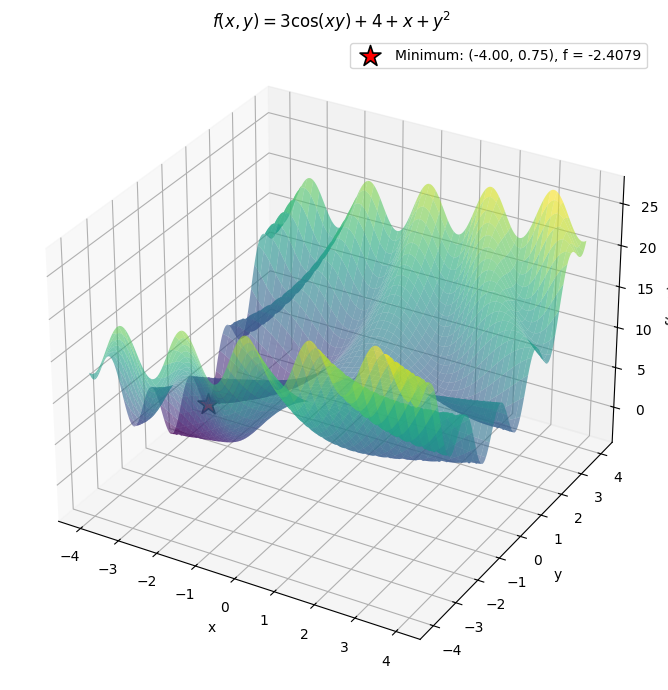

In [21]:
# 创建网格
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
Z = 3 * np.cos(X * Y) + 4 + X + Y**2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 绘制半透明曲面（alpha=0.6）
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, linewidth=0, antialiased=True)

# 标注最小值点
ax.scatter(
    optimal_x[0], optimal_x[1], optimal_f,
    color='red', s=250, marker='*',
    label=f'Minimum: ({optimal_x[0]:.2f}, {optimal_x[1]:.2f}), f = {optimal_f:.4f}',
    zorder=10,          # 高绘制层级
    edgecolors='black', # 黑边突出
    linewidth=1.2
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title(r'$f(x, y) = 3\cos(xy) + 4 + x + y^2$')
ax.legend()


plt.tight_layout()
plt.show()